## Figure 7: Signal enrichment analysis (Growth cones and Branch sites) ##

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [5]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

## Step 1: Compile background signal measurements per channel ##

For each channel, background measurements are MGV averaged over ROIs traced within images, and are saved as "BG_" .csv files. BG for EML4, MAP2, and MAP7D1 are analyzed separately, in separate analysis folders to prevent file convolution.

In [7]:
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import re

# --------------------------------------------------------
# Select folder containing all CSV files
# --------------------------------------------------------

print("Select folder containing all ROI measurement CSVs")

folder = filedialog.askdirectory(
    title="Select folder containing ROI CSV files"
)

DATA_DIR = Path(folder)

print(f"\nSelected folder:\n{DATA_DIR}\n")

# --------------------------------------------------------
# Parse filenames
# --------------------------------------------------------

def parse_filename(path):

    stem = path.stem

    pattern = (
        r"^(?P<roi_type>BG|GC|Soma)_"
        r"(?P<div>DIV\d+)_"
        r"(?P<fov>FOV\d+)_"
        r"(?P<species>TUBB3|MAP7D1|DCX)$"
    )

    match = re.match(pattern, stem)

    if match is None:
        print(f"Skipping unrecognized filename: {path.name}")
        return None

    return match.groupdict()

# --------------------------------------------------------
# Read all BG files
# --------------------------------------------------------

bg_records = []

bg_files = sorted(DATA_DIR.glob("BG_*.csv"))

print(f"Found {len(bg_files)} background files.\n")

for file in bg_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Mean" not in df.columns:
        print(f"Skipping {file.name}: no 'Mean' column found")
        continue

    bg_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "bg_mean": df["Mean"].mean(),
        "bg_sd": df["Mean"].std(),
        "n_bg_rois": len(df),
        "source_file": file.name
    })

bg_values = pd.DataFrame(bg_records)

bg_values = (
    bg_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Background summary:")
display(bg_values)

Select folder containing all ROI measurement CSVs

Selected folder:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP7D1_analysis

Found 36 background files.

Background summary:


,DIV,FOV,species,bg_mean,bg_sd,n_bg_rois,source_file
0,DIV2,FOV1,DCX,112.135133,1.780293,15,BG_DIV2_FOV1_DCX.csv
1,DIV2,FOV1,MAP7D1,186.131400,16.941215,15,BG_DIV2_FOV1_MAP7D1.csv
2,DIV2,FOV1,TUBB3,127.731267,5.936950,15,BG_DIV2_FOV1_TUBB3.csv
3,DIV2,FOV2,DCX,113.287111,1.895146,9,BG_DIV2_FOV2_DCX.csv
4,DIV2,FOV2,MAP7D1,175.182556,37.822513,9,BG_DIV2_FOV2_MAP7D1.csv
5,DIV2,FOV2,TUBB3,123.266667,3.266076,9,BG_DIV2_FOV2_TUBB3.csv
6,DIV2,FOV3,DCX,88.647833,1.217398,12,BG_DIV2_FOV3_DCX.csv
7,DIV2,FOV3,MAP7D1,130.759750,6.229626,12,BG_DIV2_FOV3_MAP7D1.csv
8,DIV2,FOV3,TUBB3,99.604167,1.952832,12,BG_DIV2_FOV3_TUBB3.csv
9,DIV3,FOV1,DCX,101.650133,1.756344,15,BG_DIV3_FOV1_DCX.csv


## Step 2: Compile Max signal measurements per channel ##

Max signal is averaged over ROIs of Soma, where signal is enriched in each channel. Files used for normalization of max signal are "Soma_" .csv files.

In [8]:
# --------------------------------------------------------
# Read all Soma files
# --------------------------------------------------------

soma_records = []

soma_files = sorted(DATA_DIR.glob("Soma_*.csv"))

print(f"Found {len(soma_files)} soma files.\n")

for file in soma_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Max" not in df.columns:
        print(f"Skipping {file.name}: no 'Max' column found")
        continue

    soma_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "positive_max": df["Max"].mean(),
        "positive_sd": df["Max"].std(),
        "n_soma_rois": len(df),
        "source_file": file.name
    })

soma_values = pd.DataFrame(soma_records)

soma_values = (
    soma_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Positive control summary:")
display(soma_values)

Found 36 soma files.

Positive control summary:


,DIV,FOV,species,positive_max,positive_sd,n_soma_rois,source_file
0,DIV2,FOV1,DCX,599.454545,98.993296,11,Soma_DIV2_FOV1_DCX.csv
1,DIV2,FOV1,MAP7D1,5801.454545,1664.045334,11,Soma_DIV2_FOV1_MAP7D1.csv
2,DIV2,FOV1,TUBB3,1438.000000,304.538011,11,Soma_DIV2_FOV1_TUBB3.csv
3,DIV2,FOV2,DCX,734.400000,109.591514,5,Soma_DIV2_FOV2_DCX.csv
4,DIV2,FOV2,MAP7D1,4568.800000,1318.906062,5,Soma_DIV2_FOV2_MAP7D1.csv
5,DIV2,FOV2,TUBB3,1743.400000,285.646285,5,Soma_DIV2_FOV2_TUBB3.csv
6,DIV2,FOV3,DCX,695.500000,153.513843,10,Soma_DIV2_FOV3_DCX.csv
7,DIV2,FOV3,MAP7D1,5725.300000,1720.615914,10,Soma_DIV2_FOV3_MAP7D1.csv
8,DIV2,FOV3,TUBB3,1434.100000,389.656387,10,Soma_DIV2_FOV3_TUBB3.csv
9,DIV3,FOV1,DCX,989.636364,250.097690,11,Soma_DIV3_FOV1_DCX.csv


## Step 3: Compile growth cone intensity measurements ##

Growth cone intensity measurements are MGV values averaged across growth cone ROIs in each channel, labeled as "GC_" .csv files.

The same script can be modified for "Branch_" .csv files.

In [9]:
# --------------------------------------------------------
# Read all GC files and normalize to matching BG + Soma
# --------------------------------------------------------

gc_records = []

gc_files = sorted(DATA_DIR.glob("GC_*.csv"))

print(f"Found {len(gc_files)} GC files.\n")

# Make lookup tables
bg_lookup = (
    bg_values
    .set_index(["DIV", "FOV", "species"])["bg_mean"]
    .to_dict()
)

soma_lookup = (
    soma_values
    .set_index(["DIV", "FOV", "species"])["positive_max"]
    .to_dict()
)

for file in gc_files:

    info = parse_filename(file)

    if info is None:
        continue

    div = info["div"]
    fov = info["fov"]
    species = info["species"]

    key = (div, fov, species)

    if key not in bg_lookup:
        print(f"Skipping {file.name}: no matching BG value found")
        continue

    if key not in soma_lookup:
        print(f"Skipping {file.name}: no matching Soma value found")
        continue

    bg = bg_lookup[key]
    soma_max = soma_lookup[key]

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Mean" not in df.columns:
        print(f"Skipping {file.name}: no 'Mean' column found")
        continue

    if "" in df.columns:
        df = df.drop(columns=[""])

    for i, row in df.iterrows():

        roi_mean = row["Mean"]

        denom = soma_max - bg

        if denom == 0:
            norm_mean = np.nan
        else:
            norm_mean = (roi_mean - bg) / denom

        gc_records.append({
            "DIV": div,
            "FOV": fov,
            "species": species,
            "ROI_type": "GC",
            "roi_id": f"ROI_{i}",

            "roi_mean_raw": roi_mean,
            "bg_mean": bg,
            "soma_positive_max": soma_max,
            "roi_mean_norm": norm_mean,

            "source_file": file.name
        })

gc_values = pd.DataFrame(gc_records)

gc_values = (
    gc_values
    .sort_values(["DIV", "FOV", "roi_id", "species"])
    .reset_index(drop=True)
)

display(gc_values)

Found 36 GC files.



,DIV,FOV,species,ROI_type,roi_id,roi_mean_raw,bg_mean,soma_positive_max,roi_mean_norm,source_file
0,DIV2,FOV1,DCX,GC,ROI_0,248.436,112.135133,599.454545,0.279695,GC_DIV2_FOV1_DCX.csv
1,DIV2,FOV1,MAP7D1,GC,ROI_0,304.493,186.131400,5801.454545,0.021078,GC_DIV2_FOV1_MAP7D1.csv
2,DIV2,FOV1,TUBB3,GC,ROI_0,483.829,127.731267,1438.000000,0.271775,GC_DIV2_FOV1_TUBB3.csv
3,DIV2,FOV1,DCX,GC,ROI_1,264.835,112.135133,599.454545,0.313347,GC_DIV2_FOV1_DCX.csv
4,DIV2,FOV1,MAP7D1,GC,ROI_1,573.765,186.131400,5801.454545,0.069031,GC_DIV2_FOV1_MAP7D1.csv
...,...,...,...,...,...,...,...,...,...,...
1256,DIV5,FOV3,TUBB3,GC,ROI_7,743.482,131.837909,4237.375000,0.148980,GC_DIV5_FOV3_TUBB3.csv
1257,DIV5,FOV3,MAP7D1,GC,ROI_8,106.864,93.654909,1961.250000,0.007073,GC_DIV5_FOV3_MAP7D1.csv
1258,DIV5,FOV3,TUBB3,GC,ROI_8,643.057,131.837909,4237.375000,0.124519,GC_DIV5_FOV3_TUBB3.csv
1259,DIV5,FOV3,MAP7D1,GC,ROI_9,106.335,93.654909,1961.250000,0.006790,GC_DIV5_FOV3_MAP7D1.csv


## Step 4: Calculate MAP signal compared to TUBB3 at GCs ##

The script can be modified for analysis of "Branch_" .csv files.

Output directory:
C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios

Species found in gc_values:
['DCX', 'MAP7D1', 'TUBB3']

DCX:TUBB3: excluding 53 ROI(s) because one of the two channels is missing.

Number of ratios generated:


,ratio_name,DIV,n_GCs
0,DCX:TUBB3,DIV2,89
1,DCX:TUBB3,DIV3,153
2,DCX:TUBB3,DIV4,143
3,MAP7D1:TUBB3,DIV2,89
4,MAP7D1:TUBB3,DIV3,153
5,MAP7D1:TUBB3,DIV4,143
6,MAP7D1:TUBB3,DIV5,53



Individual GC ratio table:


,DIV,FOV,roi_id,numerator_species,denominator_species,ratio_name,numerator_norm,TUBB3_norm,ratio
0,DIV2,FOV1,ROI_0,DCX,TUBB3,DCX:TUBB3,0.279695,0.271775,1.029144
1,DIV2,FOV1,ROI_1,DCX,TUBB3,DCX:TUBB3,0.313347,0.309494,1.012447
2,DIV2,FOV1,ROI_10,DCX,TUBB3,DCX:TUBB3,0.231365,0.247473,0.934913
3,DIV2,FOV1,ROI_11,DCX,TUBB3,DCX:TUBB3,0.262959,0.276215,0.952008
4,DIV2,FOV1,ROI_12,DCX,TUBB3,DCX:TUBB3,0.291242,0.307195,0.948069
...,...,...,...,...,...,...,...,...,...
818,DIV5,FOV3,ROI_5,MAP7D1,TUBB3,MAP7D1:TUBB3,0.031216,0.249152,0.125287
819,DIV5,FOV3,ROI_6,MAP7D1,TUBB3,MAP7D1:TUBB3,0.019467,0.173389,0.112273
820,DIV5,FOV3,ROI_7,MAP7D1,TUBB3,MAP7D1:TUBB3,0.005349,0.148980,0.035905
821,DIV5,FOV3,ROI_8,MAP7D1,TUBB3,MAP7D1:TUBB3,0.007073,0.124519,0.056801



FOV-level ratio table:


...


Ratio coverage by FOV:


ratio_name,DIV,FOV,DCX:TUBB3,MAP7D1:TUBB3
0,DIV2,FOV1,33,33
1,DIV2,FOV2,23,23
2,DIV2,FOV3,33,33
3,DIV3,FOV1,40,40
4,DIV3,FOV2,62,62
5,DIV3,FOV3,51,51
6,DIV4,FOV1,37,37
7,DIV4,FOV2,33,33
8,DIV4,FOV3,28,28
9,DIV4,FOV4,45,45



DIV-level summary across FOVs:


,ratio_name,numerator_species,DIV,ratio_mean,ratio_sem,n_FOVs,total_GCs
0,DCX:TUBB3,DCX,DIV2,1.055521,0.028188,3,89
1,DCX:TUBB3,DCX,DIV3,1.051265,0.022042,3,153
2,DCX:TUBB3,DCX,DIV4,0.988600,0.039114,4,143
3,MAP7D1:TUBB3,MAP7D1,DIV2,0.323748,0.028968,3,89
4,MAP7D1:TUBB3,MAP7D1,DIV3,0.218960,0.032111,3,153
5,MAP7D1:TUBB3,MAP7D1,DIV4,0.274957,0.078832,4,143
6,MAP7D1:TUBB3,MAP7D1,DIV5,0.155783,0.050671,3,53



Saved data files:
C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios\MAP7D1_DCX_TUBB3_ratio_per_GC_20260827.csv
C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios\MAP7D1_DCX_TUBB3_ratio_per_FOV_20260827.csv
C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios\MAP7D1_DCX_TUBB3_ratio_per_DIV_20260827.csv
Saved: C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios\MAP7D1_DCX_TUBB3_combined_GC_ratios_20260827.svg
Saved: C:\Users\Brandi\Brouhard Lab\Scripts\Jupyter - Github\brouhardlab-scripts\MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios\MAP7D1_DCX_TUBB3_combined_GC_ratios_20260827.png


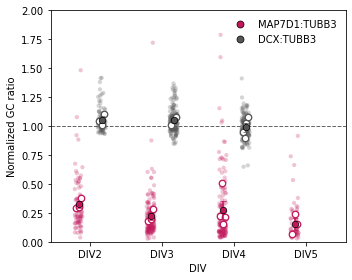

In [11]:
# ============================================================
# COMPLETE GC RATIO ANALYSIS
# Calculates:
#   1. MAP7D1:TUBB3 per growth cone
#   2. DCX:TUBB3 per growth cone
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime


# ============================================================
# 1. CONFIGURATION
# ============================================================

NUMERATOR_SPECIES = ["DCX"]
DENOMINATOR_SPECIES = "TUBB3"

VALUE_COL = "roi_mean_norm"

DIV_ORDER = ["DIV2", "DIV3", "DIV4", "DIV5"]

# Exclude normalized TUBB3 values close to zero.
DENOMINATOR_FLOOR = 0.02

RATIO_COLORS = {
    "MAP7D1:TUBB3": "#C2185B",
    "DCX:TUBB3": "#555555"
}

date = datetime.now().strftime("%Y%m%d")

# Creates an output folder beside the notebook.
RATIO_OUT_DIR = (
    Path.cwd()
    / "MAP7D1_TUBB3_and_DCX_TUBB3_GC_ratios"
)

RATIO_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Output directory:\n{RATIO_OUT_DIR.resolve()}")


# ============================================================
# 2. CHECK gc_values
# ============================================================

if "gc_values" not in globals():
    raise NameError(
        "gc_values does not exist. Run the GC import and "
        "normalization code before running this cell."
    )

required_columns = {
    "DIV",
    "FOV",
    "roi_id",
    "species",
    VALUE_COL
}

missing_columns = required_columns.difference(
    gc_values.columns
)

if missing_columns:
    raise KeyError(
        "gc_values is missing these required columns:\n"
        + "\n".join(sorted(missing_columns))
    )

print("\nSpecies found in gc_values:")
print(sorted(gc_values["species"].dropna().unique()))

required_species = set(
    NUMERATOR_SPECIES + [DENOMINATOR_SPECIES]
)

available_species = set(
    gc_values["species"].dropna().unique()
)

missing_species = required_species.difference(
    available_species
)

if missing_species:
    raise ValueError(
        "The following species were not found in gc_values:\n"
        + "\n".join(sorted(missing_species))
    )


# ============================================================
# 3. FUNCTION TO CALCULATE ONE GC RATIO
# ============================================================

def calculate_gc_ratio(
    gc_df,
    numerator_species,
    denominator_species="TUBB3",
    value_col="roi_mean_norm",
    denominator_floor=0.02
):
    """
    Match numerator and denominator measurements using
    DIV, FOV, and roi_id, then calculate one ratio per GC.
    """

    selected = gc_df[
        gc_df["species"].isin(
            [numerator_species, denominator_species]
        )
    ].copy()

    # Check for duplicate species measurements within an ROI.
    duplicate_mask = selected.duplicated(
        subset=["DIV", "FOV", "roi_id", "species"],
        keep=False
    )

    if duplicate_mask.any():
        print(
            f"\nWarning for "
            f"{numerator_species}:{denominator_species}: "
            "duplicate DIV/FOV/roi_id/species combinations "
            "were found. Duplicate values will be averaged."
        )

    # Convert species rows into separate columns.
    paired = (
        selected
        .pivot_table(
            index=["DIV", "FOV", "roi_id"],
            columns="species",
            values=value_col,
            aggfunc="mean"
        )
        .reset_index()
    )

    paired.columns.name = None

    for species in [
        numerator_species,
        denominator_species
    ]:
        if species not in paired.columns:
            raise ValueError(
                f"No usable {species} values were found."
            )

    # Identify incomplete pairs.
    incomplete_mask = paired[
        [numerator_species, denominator_species]
    ].isna().any(axis=1)

    n_incomplete = incomplete_mask.sum()

    if n_incomplete > 0:
        print(
            f"\n{numerator_species}:{denominator_species}: "
            f"excluding {n_incomplete} ROI(s) because one "
            "of the two channels is missing."
        )

    paired = paired[~incomplete_mask].copy()

    # Keep finite values only.
    finite_mask = (
        np.isfinite(paired[numerator_species])
        & np.isfinite(paired[denominator_species])
    )

    n_nonfinite = (~finite_mask).sum()

    if n_nonfinite > 0:
        print(
            f"{numerator_species}:{denominator_species}: "
            f"excluding {n_nonfinite} ROI(s) containing "
            "non-finite values."
        )

    paired = paired[finite_mask].copy()

    # Prevent division by zero or near-zero TUBB3.
    denominator_valid = (
        paired[denominator_species]
        >= denominator_floor
    )

    n_below_floor = (~denominator_valid).sum()

    if n_below_floor > 0:
        print(
            f"{numerator_species}:{denominator_species}: "
            f"excluding {n_below_floor} ROI(s) because "
            f"normalized {denominator_species} was below "
            f"{denominator_floor}."
        )

    paired = paired[denominator_valid].copy()

    # Give both ratios the same tidy column names.
    paired = paired.rename(
        columns={
            numerator_species: "numerator_norm",
            denominator_species: "TUBB3_norm"
        }
    )

    paired["numerator_species"] = numerator_species
    paired["denominator_species"] = denominator_species

    paired["ratio_name"] = (
        f"{numerator_species}:{denominator_species}"
    )

    paired["ratio"] = (
        paired["numerator_norm"]
        / paired["TUBB3_norm"]
    )

    return paired[
        [
            "DIV",
            "FOV",
            "roi_id",
            "numerator_species",
            "denominator_species",
            "ratio_name",
            "numerator_norm",
            "TUBB3_norm",
            "ratio"
        ]
    ]


# ============================================================
# ============================================================
# 4. CALCULATE EACH RATIO INDEPENDENTLY
# ============================================================

# MAP7D1 only needs matching MAP7D1 and TUBB3 data.
MAP7D1_ratio_df = calculate_gc_ratio(
    gc_df=gc_values,
    numerator_species="MAP7D1",
    denominator_species="TUBB3",
    value_col="roi_mean_norm",
    denominator_floor=DENOMINATOR_FLOOR
)

# DCX only needs matching DCX and TUBB3 data.
dcx_ratio_df = calculate_gc_ratio(
    gc_df=gc_values,
    numerator_species="DCX",
    denominator_species="TUBB3",
    value_col="roi_mean_norm",
    denominator_floor=DENOMINATOR_FLOOR
)

# Combine the finished ratio tables.
# Missing DCX cannot remove MAP7D1 here.
gc_ratio_df = pd.concat(
    [
        MAP7D1_ratio_df,
        dcx_ratio_df
    ],
    ignore_index=True
)

gc_ratio_df = (
    gc_ratio_df
    .sort_values(
        ["ratio_name", "DIV", "FOV", "roi_id"]
    )
    .reset_index(drop=True)
)

if gc_ratio_df.empty:
    raise ValueError(
        "No paired GC ratios were generated."
    )

print("\nNumber of ratios generated:")

display(
    gc_ratio_df
    .groupby(["ratio_name", "DIV"])
    .size()
    .rename("n_GCs")
    .reset_index()
)

print("\nIndividual GC ratio table:")
display(gc_ratio_df)


# ============================================================
# 5. CALCULATE FOV SUMMARIES
# ============================================================

fov_ratio_df = (
    gc_ratio_df
    .groupby(
        [
            "ratio_name",
            "numerator_species",
            "DIV",
            "FOV"
        ],
        as_index=False
    )
    .agg(
        ratio_mean=("ratio", "mean"),
        ratio_median=("ratio", "median"),
        ratio_sem=(
            "ratio",
            lambda x: (
                x.std(ddof=1) / np.sqrt(x.count())
                if x.count() > 1
                else np.nan
            )
        ),
        n_GCs=("ratio", "count")
    )
)

print("\nFOV-level ratio table:")
display(fov_ratio_df)


# ============================================================
# CHECK WHICH FOVs CONTRIBUTE TO EACH RATIO
# ============================================================

ratio_coverage = (
    gc_ratio_df
    .groupby(["DIV", "FOV", "ratio_name"])
    .size()
    .unstack("ratio_name", fill_value=0)
    .reset_index()
)

print("\nRatio coverage by FOV:")
display(ratio_coverage)
# ============================================================
# 6. CALCULATE DIV SUMMARY ACROSS FOVs
# ============================================================

div_ratio_df = (
    fov_ratio_df
    .groupby(
        [
            "ratio_name",
            "numerator_species",
            "DIV"
        ],
        as_index=False
    )
    .agg(
        ratio_mean=("ratio_mean", "mean"),
        ratio_sem=(
            "ratio_mean",
            lambda x: (
                x.std(ddof=1) / np.sqrt(x.count())
                if x.count() > 1
                else np.nan
            )
        ),
        n_FOVs=("ratio_mean", "count"),
        total_GCs=("n_GCs", "sum")
    )
)

print("\nDIV-level summary across FOVs:")
display(div_ratio_df)


# ============================================================
# 7. EXPORT ALL TABLES
# ============================================================

gc_ratio_path = (
    RATIO_OUT_DIR
    / f"MAP7D1_DCX_TUBB3_ratio_per_GC_{date}.csv"
)

fov_ratio_path = (
    RATIO_OUT_DIR
    / f"MAP7D1_DCX_TUBB3_ratio_per_FOV_{date}.csv"
)

div_ratio_path = (
    RATIO_OUT_DIR
    / f"MAP7D1_DCX_TUBB3_ratio_per_DIV_{date}.csv"
)

gc_ratio_df.to_csv(
    gc_ratio_path,
    index=False
)

fov_ratio_df.to_csv(
    fov_ratio_path,
    index=False
)

div_ratio_df.to_csv(
    div_ratio_path,
    index=False
)

print("\nSaved data files:")
print(gc_ratio_path)
print(fov_ratio_path)
print(div_ratio_path)


# ============================================================
# COMBINED PLOT:
# MAP7D1:TUBB3 AND DCX:TUBB3 ON THE SAME AXES
#
# Small transparent points = individual GCs
# Open circles = individual FOV means
# Large solid circles = mean ± SEM across FOVs
# ============================================================

ratio_order = [
    "MAP7D1:TUBB3",
    "DCX:TUBB3"
]

ratio_colors = {
    "MAP7D1:TUBB3": "#C2185B",
    "DCX:TUBB3": "#555555"
}

# Horizontal offset for each ratio within a DIV.
ratio_offsets = {
    "MAP7D1:TUBB3": -0.16,
    "DCX:TUBB3": 0.16
}

fig, ax = plt.subplots(figsize=(5, 4))

x_positions = np.arange(len(DIV_ORDER))

# Reproducible jitter.
rng = np.random.default_rng(42)

for ratio_name in ratio_order:

    color = ratio_colors[ratio_name]
    ratio_offset = ratio_offsets[ratio_name]

    for base_x, div in zip(
        x_positions,
        DIV_ORDER
    ):

        ratio_x = base_x + ratio_offset

        # ----------------------------------------------------
        # Individual GC ratios
        # ----------------------------------------------------

        individual_values = (
            gc_ratio_df.loc[
                (
                    gc_ratio_df["ratio_name"]
                    == ratio_name
                )
                & (
                    gc_ratio_df["DIV"]
                    == div
                ),
                "ratio"
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(individual_values) > 0:

            gc_jitter = rng.uniform(
                -0.055,
                0.055,
                size=len(individual_values)
            )

            ax.scatter(
                (
                    np.full(
                        len(individual_values),
                        ratio_x
                    )
                    + gc_jitter
                ),
                individual_values,
                s=18,
                alpha=0.25,
                color=color,
                edgecolors="none",
                zorder=1
            )

        # ----------------------------------------------------
        # Individual FOV means
        # ----------------------------------------------------

        div_fovs = fov_ratio_df[
            (
                fov_ratio_df["ratio_name"]
                == ratio_name
            )
            & (
                fov_ratio_df["DIV"]
                == div
            )
        ].copy()

        if div_fovs.empty:
            continue

        fov_offsets = np.linspace(
            -0.035,
            0.035,
            len(div_fovs)
        )

        ax.scatter(
            (
                np.full(
                    len(div_fovs),
                    ratio_x
                )
                + fov_offsets
            ),
            div_fovs["ratio_mean"],
            s=42,
            facecolors="white",
            edgecolors=color,
            linewidths=1.3,
            zorder=3
        )

        # ----------------------------------------------------
        # Mean ± SEM across FOVs
        # ----------------------------------------------------

        grand_mean = (
            div_fovs["ratio_mean"].mean()
        )

        if len(div_fovs) > 1:
            grand_sem = (
                div_fovs["ratio_mean"].std(ddof=1)
                / np.sqrt(len(div_fovs))
            )
        else:
            grand_sem = np.nan

        ax.errorbar(
            ratio_x,
            grand_mean,
            yerr=grand_sem,
            fmt="o",
            markersize=6.5,
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.7,
            ecolor=color,
            capsize=3,
            linewidth=1.6,
            zorder=4
        )


# ============================================================
# FORMATTING
# ============================================================

ax.axhline(
    1,
    linestyle="--",
    linewidth=1,
    color="black",
    alpha=0.6,
    zorder=0
)

ax.set_xticks(x_positions)
ax.set_xticklabels(DIV_ORDER)

ax.set_xlabel("DIV")
ax.set_ylabel("Normalized GC ratio")

# Add space around the first and last DIV.
ax.set_xlim(
    -0.55,
    len(DIV_ORDER) - 0.45
)

# Uncomment this if you want to enforce a specific y-axis.
# Change the upper value as appropriate for your data.
#
ax.set_ylim(0, 2.0)

# Create a clean ratio legend.
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=ratio_colors[ratio_name],
        markeredgecolor="black",
        markeredgewidth=0.7,
        markersize=7,
        label=ratio_name
    )
    for ratio_name in ratio_order
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="best"
)

plt.tight_layout()


# ============================================================
# SAVE COMBINED PLOT
# ============================================================

combined_plot_svg = (
    RATIO_OUT_DIR
    / f"MAP7D1_DCX_TUBB3_combined_GC_ratios_{date}.svg"
)

combined_plot_png = (
    RATIO_OUT_DIR
    / f"MAP7D1_DCX_TUBB3_combined_GC_ratios_{date}.png"
)

plt.savefig(
    combined_plot_svg,
    bbox_inches="tight"
)

plt.savefig(
    combined_plot_png,
    dpi=600,
    bbox_inches="tight"
)

print(f"Saved: {combined_plot_svg}")
print(f"Saved: {combined_plot_png}")

plt.show()

## Step 5: Calculate and plot Pearson coefficients for growth cone ROIs ##

Script calculates Pearson between MAP/DCX and TUBB3 within "GC_" or "Branch_" .csv files.

In [15]:
# ============================================================
# CALCULATE GC PEARSON CORRELATIONS
# One Pearson r per FOV, calculated across matched GC ROIs
# ============================================================

from scipy.stats import pearsonr


PEARSON_COMPARISONS = {
    "TUBB3 vs DCX": ("TUBB3", "DCX"),
    "TUBB3 vs MAP7D1": ("TUBB3", "MAP7D1")
}

MIN_MATCHED_GCS = 3


# ------------------------------------------------------------
# Check that each DIV/FOV/ROI has no duplicate species values
# ------------------------------------------------------------

duplicate_measurements = (
    gc_values
    .groupby(
        ["DIV", "FOV", "roi_id", "species"],
        observed=True
    )
    .size()
    .reset_index(name="n")
)

duplicate_measurements = duplicate_measurements[
    duplicate_measurements["n"] > 1
]

if not duplicate_measurements.empty:
    raise ValueError(
        "Duplicate species measurements were found for some "
        "DIV/FOV/ROI combinations:\n"
        f"{duplicate_measurements.to_string(index=False)}"
    )


# ------------------------------------------------------------
# Put matched species measurements into separate columns
#
# Each row now represents one GC ROI.
# ------------------------------------------------------------

gc_wide = (
    gc_values
    .pivot(
        index=["DIV", "FOV", "roi_id"],
        columns="species",
        values="roi_mean_norm"
    )
    .reset_index()
)

gc_wide.columns.name = None

print("Matched GC measurements:")
display(gc_wide.head())


# ------------------------------------------------------------
# Calculate one Pearson coefficient per FOV
#
# Within each FOV, Pearson r is calculated across matched
# growth-cone ROIs.
# ------------------------------------------------------------

pearson_records = []

for (div, fov), fov_data in gc_wide.groupby(
    ["DIV", "FOV"],
    observed=True
):

    for comparison, (species_1, species_2) in (
        PEARSON_COMPARISONS.items()
    ):

        if (
            species_1 not in fov_data.columns
            or species_2 not in fov_data.columns
        ):
            print(
                f"Skipping {div}, {fov}, {comparison}: "
                "one or both species are absent"
            )
            continue

        paired = (
            fov_data[
                ["roi_id", species_1, species_2]
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(
                subset=[species_1, species_2]
            )
        )

        n_matched_gcs = len(paired)

        if n_matched_gcs < MIN_MATCHED_GCS:
            print(
                f"Skipping {div}, {fov}, {comparison}: "
                f"only {n_matched_gcs} matched GC ROIs"
            )
            continue

        # Pearson r is undefined if either species has
        # zero variance across the growth cones.
        if (
            paired[species_1].nunique() < 2
            or paired[species_2].nunique() < 2
        ):
            print(
                f"Skipping {div}, {fov}, {comparison}: "
                "one species has no variance"
            )
            continue

        pearson_r, pearson_p = pearsonr(
            paired[species_1],
            paired[species_2]
        )

        pearson_records.append(
            {
                "DIV": div,
                "FOV": fov,
                "comparison": comparison,
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "n_matched_gcs": n_matched_gcs
            }
        )


pearson_gc = pd.DataFrame(pearson_records)

if pearson_gc.empty:
    raise ValueError(
        "No GC Pearson coefficients were generated. "
        "Check the species labels and matched ROI identifiers."
    )

pearson_gc = (
    pearson_gc
    .sort_values(["DIV", "comparison", "FOV"])
    .reset_index(drop=True)
)


# ============================================================
# SUMMARIZE PEARSON r ACROSS FOVs
# ============================================================

pearson_gc_summary = (
    pearson_gc
    .groupby(
        ["DIV", "comparison"],
        as_index=False,
        observed=True
    )
    .agg(
        mean_r=("pearson_r", "mean"),
        sem_r=(
            "pearson_r",
            lambda values: (
                values.std(ddof=1)
                / np.sqrt(values.notna().sum())
                if values.notna().sum() > 1
                else np.nan
            )
        ),
        n_fovs=("pearson_r", "count")
    )
)


print("\nPearson coefficients calculated within each FOV:")
display(pearson_gc)

print("\nMean ± SEM across FOVs:")
display(pearson_gc_summary)

Matched GC measurements:


,DIV,FOV,roi_id,DCX,MAP7D1,TUBB3
0,DIV2,FOV1,ROI_0,0.279695,0.021078,0.271775
1,DIV2,FOV1,ROI_1,0.313347,0.069031,0.309494
2,DIV2,FOV1,ROI_10,0.231365,0.064971,0.247473
3,DIV2,FOV1,ROI_11,0.262959,0.010317,0.276215
4,DIV2,FOV1,ROI_12,0.291242,0.049343,0.307195


Skipping DIV5, FOV1, TUBB3 vs DCX: only 0 matched GC ROIs
Skipping DIV5, FOV2, TUBB3 vs DCX: only 0 matched GC ROIs
Skipping DIV5, FOV3, TUBB3 vs DCX: only 0 matched GC ROIs

Pearson coefficients calculated within each FOV:


,DIV,FOV,comparison,pearson_r,pearson_p,n_matched_gcs
0,DIV2,FOV1,TUBB3 vs DCX,0.966185,8.302685e-20,33
1,DIV2,FOV2,TUBB3 vs DCX,0.950164,4.225042e-12,23
2,DIV2,FOV3,TUBB3 vs DCX,0.965991,9.058909e-20,33
3,DIV2,FOV1,TUBB3 vs MAP7D1,0.010717,9.527977e-01,33
4,DIV2,FOV2,TUBB3 vs MAP7D1,0.139979,5.241064e-01,23
5,DIV2,FOV3,TUBB3 vs MAP7D1,0.171561,3.397575e-01,33
6,DIV3,FOV1,TUBB3 vs DCX,0.932040,2.428077e-18,40
7,DIV3,FOV2,TUBB3 vs DCX,0.940935,6.559697e-30,62
8,DIV3,FOV3,TUBB3 vs DCX,0.965458,2.809309e-30,51
9,DIV3,FOV1,TUBB3 vs MAP7D1,0.628983,1.380834e-05,40



Mean ± SEM across FOVs:


,DIV,comparison,mean_r,sem_r,n_fovs
0,DIV2,TUBB3 vs DCX,0.960780,0.005308,3
1,DIV2,TUBB3 vs MAP7D1,0.107419,0.049203,3
2,DIV3,TUBB3 vs DCX,0.946144,0.009992,3
3,DIV3,TUBB3 vs MAP7D1,0.532647,0.068899,3
4,DIV4,TUBB3 vs DCX,0.981518,0.004723,4
5,DIV4,TUBB3 vs MAP7D1,0.614551,0.079749,4
6,DIV5,TUBB3 vs MAP7D1,0.780796,0.076173,3


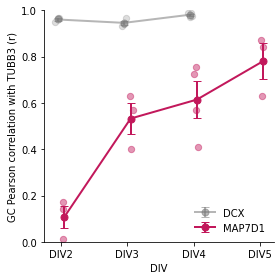

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------------------------------------------------------
# Plot GC Pearson coefficients by DIV
# Scatter = one FOV
# Error bars = mean ± SEM across FOVs
# --------------------------------------------------------
from pathlib import Path

# Output folder for Pearson plots
PEARSON_OUT_DIR = Path("Pearson_GC_outputs")
PEARSON_OUT_DIR.mkdir(parents=True, exist_ok=True)


plot_points = pearson_gc.copy()
plot_summary = pearson_gc_summary.copy()

colors = {
    "TUBB3 vs DCX": "#7A7A7A",
    "TUBB3 vs MAP7D1": "#C2185B"
}

point_alphas = {
    "TUBB3 vs DCX": 0.25,
    "TUBB3 vs MAP7D1": 0.45
}

line_alphas = {
    "TUBB3 vs DCX": 0.55,
    "TUBB3 vs MAP7D1": 1.0
}

labels = {
    "TUBB3 vs DCX": "DCX",
    "TUBB3 vs MAP7D1": "MAP7D1"
}

div_order = ["DIV2", "DIV3", "DIV4", "DIV5"]

offsets = {
    "TUBB3 vs DCX": -0.05,
    "TUBB3 vs MAP7D1": 0.05
}

fig, ax = plt.subplots(figsize=(4,4))

for comparison in ["TUBB3 vs DCX", "TUBB3 vs MAP7D1"]:

    # -------------------------
    # Scatter FOV values
    # -------------------------

    sub = plot_points[
        plot_points["comparison"] == comparison
    ].copy()

    sub["DIV"] = pd.Categorical(
        sub["DIV"],
        categories=div_order,
        ordered=True
    )

    x = sub["DIV"].cat.codes
    jitter = np.random.normal(0, 0.025, len(sub))

    ax.scatter(
        x + offsets[comparison] + jitter,
        sub["pearson_r"],
        s=40,
        color=colors[comparison],
        alpha=point_alphas[comparison]
    )

    # -------------------------
    # Mean ± SEM
    # -------------------------

    summary = plot_summary[
        plot_summary["comparison"] == comparison
    ].copy()

    summary["DIV"] = pd.Categorical(
        summary["DIV"],
        categories=div_order,
        ordered=True
    )

    summary = summary.sort_values("DIV")

    ax.errorbar(
        summary["DIV"].cat.codes + offsets[comparison],
        summary["mean_r"],
        yerr=summary["sem_r"],
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=4,
        color=colors[comparison],
        alpha=line_alphas[comparison],
        label=labels[comparison]
    )

# --------------------------------------------------------
# Formatting
# --------------------------------------------------------

ax.set_xticks(range(len(div_order)))
ax.set_xticklabels(div_order)

ax.set_xlabel("DIV")
ax.set_ylabel("GC Pearson correlation with TUBB3 (r)")
ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out")

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    PEARSON_OUT_DIR / "Pearson_GC_vs_DIV_FOVscatter.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    PEARSON_OUT_DIR / "Pearson_GC_vs_DIV_FOVscatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()